In [1]:
import numpy as np
import pandas as pd
import scipy
import yfinance as yf
from datetime import datetime, timedelta
from scipy import stats
import matplotlib.pyplot as plt

In [3]:
end_date = datetime.today()
print(end_date)

2026-05-14 14:45:08.378040


In [4]:
start_date = end_date - timedelta(2*365)
print(start_date)

2024-05-14 14:45:08.378040


In [5]:
#['NVDA'] #stock
#['BTC-USD'] #crypto
#['PFE'] #healthcare sector
#['^FVX'] #bond
#['ES=F'] #future
#['GC=F'] #commodity
#['^GSPC'] #index
#['TSLL'] #ETF
tickers = ['NVDA', 'BTC-USD','PFE', '^FVX', 'ES=F', 'GC=F', 'INR=X', '^GSPC', 'TSLL']  

In [6]:
df = yf.download(tickers, start = start_date, end = end_date, auto_adjust=False, actions = False)

[*********************100%***********************]  9 of 9 completed


In [7]:
returns = df['Adj Close'].pct_change(fill_method=None).dropna()
returns

Ticker,BTC-USD,ES=F,GC=F,INR=X,NVDA,PFE,TSLL,^FVX,^GSPC
Date,,,,,,,,,
2024-05-15,0.076596,0.012050,0.015000,0.000224,0.035838,0.015504,-0.038860,-0.022880,0.011716
2024-05-16,-0.015632,-0.002391,-0.003642,-0.001426,-0.002864,0.003470,0.006739,0.009871,-0.002082
2024-05-17,0.027905,0.001316,0.013529,0.000779,-0.019924,-0.009682,0.030790,0.009548,0.001165
2024-05-21,-0.018358,0.002532,-0.005013,0.000175,0.006394,0.001052,0.130841,-0.004712,0.002502
2024-05-22,-0.014460,-0.003227,-0.013420,0.000022,-0.004571,0.036415,-0.068477,0.008341,-0.002706
...,...,...,...,...,...,...,...,...,...
2026-05-06,0.006184,0.014031,0.027679,-0.000802,0.057659,0.003025,0.047839,-0.017191,0.014588
2026-05-07,-0.017409,-0.003586,0.003823,-0.006041,0.017659,-0.001885,0.065538,0.010495,-0.003803
2026-05-08,0.002209,0.007606,0.004383,-0.003752,0.017494,-0.014203,0.079475,-0.007666,0.008426


In [8]:
annual_return = (1+returns).prod() - 1
annual_return

Ticker
BTC-USD    0.110210
ES=F       0.103508
GC=F       0.551326
INR=X      0.091703
NVDA       1.108791
PFE       -0.045435
TSLL       0.304174
^FVX      -0.134153
^GSPC      0.209024
dtype: float64

In [9]:
annualized_returns_compounded = (1+returns).prod() ** (252/len(returns)) - 1
annualized_returns_compounded

Ticker
BTC-USD    0.070828
ES=F       0.066592
GC=F       0.332981
INR=X      0.059110
NVDA       0.629651
PFE       -0.029977
TSLL       0.189850
^FVX      -0.089977
^GSPC      0.132289
dtype: float64

In [10]:
annualized_returns_approx = (1+returns.mean())**252 - 1
annualized_returns_approx

Ticker
BTC-USD    0.169894
ES=F       0.081222
GC=F       0.367753
INR=X      0.060421
NVDA       0.822790
PFE        0.001130
TSLL       1.472050
^FVX      -0.067579
^GSPC      0.148116
dtype: float64

(array([ 0.57293966,  1.43234916,  1.14587933,  1.71881899,  2.86469831,
         5.15645696,  6.30233629, 10.88585359, 14.32349157, 15.75584073,
        16.90172005, 12.03173292,  7.44821562,  6.58880612,  2.57822848,
         1.71881899,  1.14587933,  0.        ,  0.57293966,  0.57293966,
         0.        ,  0.        ,  0.        ,  0.28646983,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.28646983]),
 array([-0.08478059, -0.07571366, -0.06664673, -0.05757979, -0.04851286,
        -0.03944593, -0.030379  , -0.02131206, -0.01224513, -0.0031782 ,
         0.00588873,  0.01495567,  0.0240226 ,  0.03308953,  0.04215646,
         0.05122339,  0.06029033,  0.06935726,  0.07842419,  0.08749112,
         0.09655806,  0.10562499,  0.11469192,  0.12375885,  0.13282579,
         0.14189272,  0.15095965,  0.16002658,  0.16909352,  0.17816045,
         0.18722738]),
 <BarContainer object of 30 artists>)

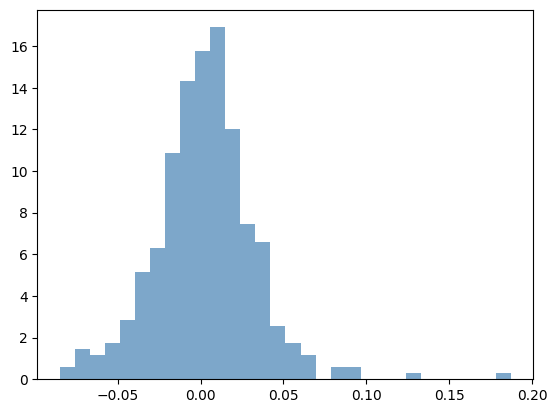

In [11]:
x1 = returns['NVDA'].squeeze().dropna()

plt.hist(x1, bins=30, density=True, alpha=0.7, color='steelblue')

(array([ 0.2923394 ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.2923394 ,  1.46169701,
         1.16935761,  4.67743042,  5.26210923, 12.57059426, 15.78632768,
        17.24802469, 18.7097217 , 11.98591546,  9.64720025,  4.09275162,
         4.96976983,  1.16935761,  1.16935761,  0.5846788 ,  0.2923394 ,
         0.2923394 ,  0.2923394 ,  0.        ,  0.        ,  0.5846788 ]),
 array([-0.14129892, -0.13241404, -0.12352915, -0.11464426, -0.10575938,
        -0.09687449, -0.0879896 , -0.07910471, -0.07021983, -0.06133494,
        -0.05245005, -0.04356516, -0.03468028, -0.02579539, -0.0169105 ,
        -0.00802562,  0.00085927,  0.00974416,  0.01862905,  0.02751393,
         0.03639882,  0.04528371,  0.05416859,  0.06305348,  0.07193837,
         0.08082326,  0.08970814,  0.09859303,  0.10747792,  0.1163628 ,
         0.12524769]),
 <BarContainer object of 30 artists>)

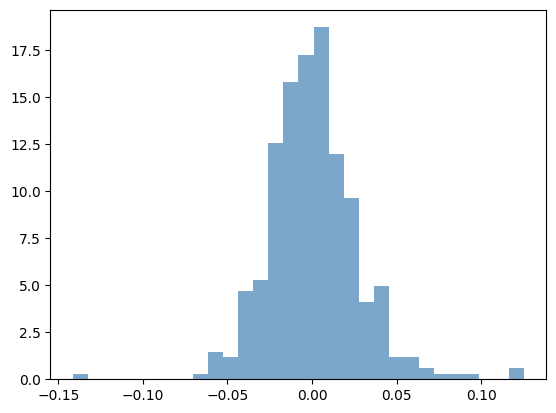

In [12]:
x1 = returns['BTC-USD'].squeeze().dropna()

plt.hist(x1, bins=30, density=True, alpha=0.7, color='steelblue')

(array([ 0.63512653,  0.63512653,  0.        ,  1.9053796 ,  1.9053796 ,
         2.54050613,  3.8107592 ,  6.98639187, 11.4322776 , 12.70253067,
        17.78354293, 22.22942867, 29.85094707, 27.94556747, 29.85094707,
        20.32404907, 24.7699348 , 10.16202453,  6.98639187,  2.54050613,
         1.27025307,  3.17563267,  1.9053796 ,  0.        ,  1.27025307,
         0.63512653,  0.        ,  0.        ,  0.        ,  1.27025307]),
 array([-0.05434362, -0.05025403, -0.04616445, -0.04207487, -0.03798529,
        -0.0338957 , -0.02980612, -0.02571654, -0.02162695, -0.01753737,
        -0.01344779, -0.00935821, -0.00526862, -0.00117904,  0.00291054,
         0.00700013,  0.01108971,  0.01517929,  0.01926887,  0.02335846,
         0.02744804,  0.03153762,  0.03562721,  0.03971679,  0.04380637,
         0.04789595,  0.05198554,  0.05607512,  0.0601647 ,  0.06425429,
         0.06834387]),
 <BarContainer object of 30 artists>)

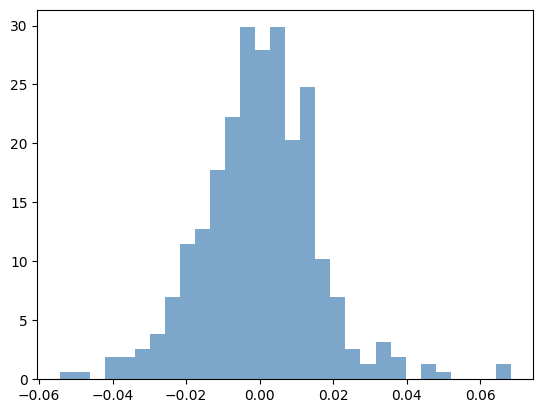

In [13]:
x1 = returns['PFE'].squeeze().dropna()

plt.hist(x1, bins=30, density=True, alpha=0.7, color='steelblue')

(array([ 0.72115239,  0.        ,  0.        ,  1.44230479,  0.        ,
         0.72115239,  0.        ,  0.72115239,  1.44230479,  3.60576196,
         7.93267632, 13.70189546, 17.30765743, 30.2884005 , 25.24033375,
        27.40379092, 26.68263853, 26.68263853, 30.2884005 , 23.79802896,
        14.42304785,  8.65382871,  5.04806675,  2.88460957,  2.16345718,
         3.60576196,  0.72115239,  0.72115239,  0.        ,  1.44230479]),
 array([-0.05908381, -0.05548207, -0.05188033, -0.04827859, -0.04467685,
        -0.04107512, -0.03747338, -0.03387164, -0.0302699 , -0.02666816,
        -0.02306642, -0.01946468, -0.01586294, -0.0122612 , -0.00865947,
        -0.00505773, -0.00145599,  0.00214575,  0.00574749,  0.00934923,
         0.01295097,  0.01655271,  0.02015445,  0.02375618,  0.02735792,
         0.03095966,  0.0345614 ,  0.03816314,  0.04176488,  0.04536662,
         0.04896836]),
 <BarContainer object of 30 artists>)

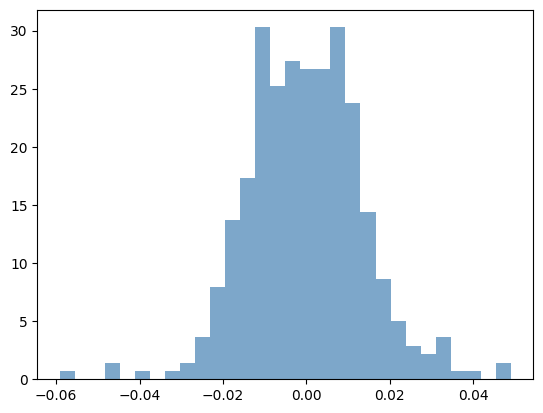

In [14]:
x1 = returns['^FVX'].squeeze().dropna()

plt.hist(x1, bins=30, density=True, alpha=0.7, color='steelblue')

(array([ 0.50885418,  0.        ,  0.50885418,  0.        ,  0.50885418,
         0.50885418,  0.50885418,  2.54427089,  9.15937522, 10.68593775,
        32.56666743, 50.88541786, 51.39427204, 25.95156311,  5.08854179,
         2.54427089,  1.52656254,  0.50885418,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.50885418]),
 array([-0.0593622 , -0.05425779, -0.04915337, -0.04404896, -0.03894454,
        -0.03384013, -0.02873572, -0.0236313 , -0.01852689, -0.01342247,
        -0.00831806, -0.00321364,  0.00189077,  0.00699519,  0.0120996 ,
         0.01720401,  0.02230843,  0.02741284,  0.03251726,  0.03762167,
         0.04272609,  0.0478305 ,  0.05293492,  0.05803933,  0.06314374,
         0.06824816,  0.07335257,  0.07845699,  0.0835614 ,  0.08866582,
         0.09377023]),
 <BarContainer object of 30 artists>)

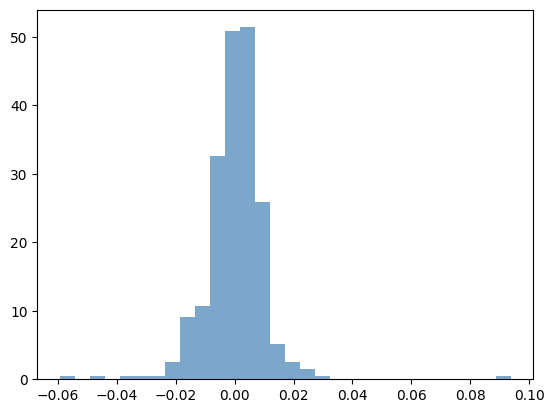

In [15]:
x1 = returns['ES=F'].squeeze().dropna()

plt.hist(x1, bins=30, density=True, alpha=0.7, color='steelblue')

(array([ 0.44655783,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.89311566,
         0.        ,  0.        ,  0.44655783,  0.89311566,  2.67934699,
         4.01902049,  4.91213615, 13.8432928 , 25.90035426, 32.59872175,
        40.19020489, 25.90035426, 11.1639458 ,  2.67934699,  3.12590482,
         1.3396735 ,  0.        ,  0.44655783,  0.        ,  0.44655783]),
 array([-0.11366201, -0.10784551, -0.10202901, -0.09621251, -0.09039601,
        -0.08457952, -0.07876302, -0.07294652, -0.06713002, -0.06131353,
        -0.05549703, -0.04968053, -0.04386403, -0.03804754, -0.03223104,
        -0.02641454, -0.02059804, -0.01478155, -0.00896505, -0.00314855,
         0.00266795,  0.00848445,  0.01430094,  0.02011744,  0.02593394,
         0.03175044,  0.03756693,  0.04338343,  0.04919993,  0.05501643,
         0.06083292]),
 <BarContainer object of 30 artists>)

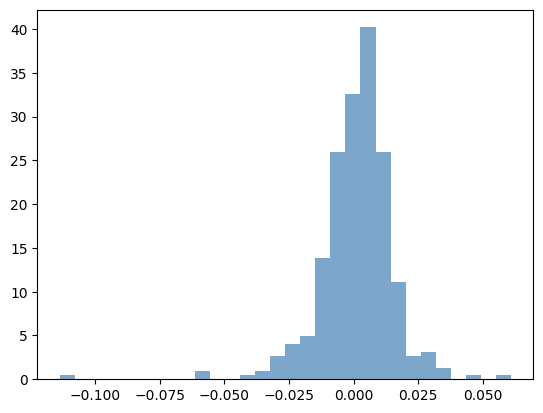

In [16]:
x1 = returns['GC=F'].squeeze().dropna()

plt.hist(x1, bins=30, density=True, alpha=0.7, color='steelblue')

(array([ 0.50303632,  0.        ,  0.50303632,  0.        ,  0.50303632,
         0.50303632,  0.50303632,  2.01214529,  9.55769014, 11.56983543,
        29.67914306, 53.32185025, 50.30363231, 24.64877983,  5.03036323,
         2.51518162,  1.50910897,  0.50303632,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.50303632]),
 array([-0.05974961, -0.05458616, -0.04942271, -0.04425926, -0.03909581,
        -0.03393236, -0.02876891, -0.02360546, -0.01844201, -0.01327856,
        -0.00811511, -0.00295166,  0.00221179,  0.00737524,  0.01253869,
         0.01770214,  0.02286558,  0.02802903,  0.03319248,  0.03835593,
         0.04351938,  0.04868283,  0.05384628,  0.05900973,  0.06417318,
         0.06933663,  0.07450008,  0.07966353,  0.08482698,  0.08999043,
         0.09515388]),
 <BarContainer object of 30 artists>)

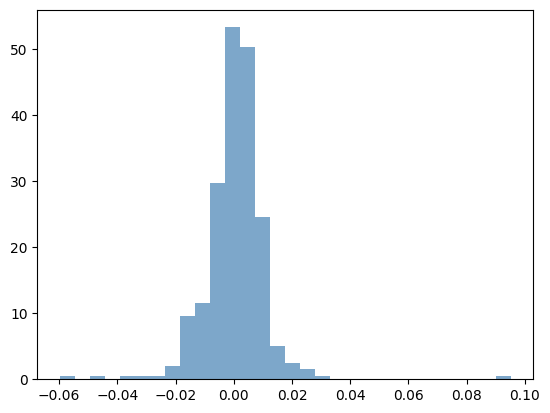

In [17]:
x1 = returns['^GSPC'].squeeze().dropna()

plt.hist(x1, bins=30, density=True, alpha=0.7, color='steelblue')

(array([0.1057114 , 0.1057114 , 0.        , 0.1057114 , 0.63426842,
        0.1057114 , 0.63426842, 1.69138244, 3.69989909, 2.74849647,
        6.02554995, 7.61122099, 4.43987891, 4.1227447 , 4.65130172,
        1.69138244, 0.95140262, 0.52855701, 0.31713421, 0.21142281,
        0.        , 0.        , 0.        , 0.1057114 , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.21142281]),
 array([-0.28498534, -0.26041464, -0.23584395, -0.21127325, -0.18670256,
        -0.16213186, -0.13756117, -0.11299047, -0.08841978, -0.06384908,
        -0.03927839, -0.01470769,  0.009863  ,  0.0344337 ,  0.05900439,
         0.08357508,  0.10814578,  0.13271647,  0.15728717,  0.18185786,
         0.20642856,  0.23099925,  0.25556995,  0.28014064,  0.30471134,
         0.32928203,  0.35385273,  0.37842342,  0.40299412,  0.42756481,
         0.4521355 ]),
 <BarContainer object of 30 artists>)

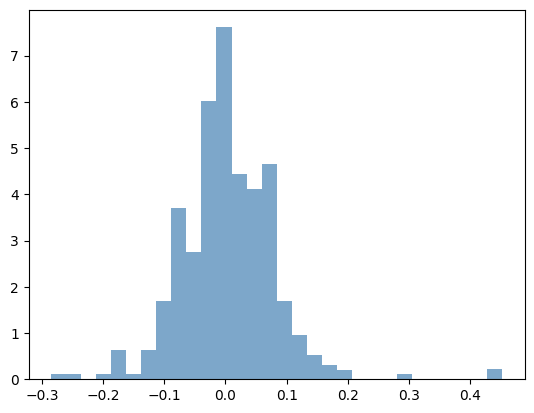

In [18]:
x1 = returns['TSLL'].squeeze().dropna()

plt.hist(x1, bins=30, density=True, alpha=0.7, color='steelblue')

In [19]:
def annualize_vol(r, periods_per_year = 252):
    return r.std() * (periods_per_year ** 0.5)
annualize_vol(returns)

Ticker
BTC-USD    0.422331
ES=F       0.165769
GC=F       0.225607
INR=X      0.049779
NVDA       0.477480
PFE        0.251910
TSLL       1.227751
^FVX       0.220674
^GSPC      0.167386
dtype: float64